In [ ]:
# HOW TO SET PATHS:
#   Place dailyActivity_merged.csv and sleepDay_merged.csv in the
#   same folder as this notebook, then run as-is.
#   The auto-detect block below handles VS Code and Colab automatically.

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Auto-detect environment and locate CSV files ─────────────────────────────
def find_csv(filename):
    """Search common locations for a CSV file and return its path."""
    candidates = [
        filename,                                      # same folder as notebook
        os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.', filename),
        os.path.join('/content', filename),            # Colab root
        os.path.join('/content/drive/MyDrive', filename),  # Colab Google Drive
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        f"Could not find '{filename}'.\n"
        "Please place it in the same folder as this notebook, or update the path manually below."
    )

# ── MANUAL OVERRIDE (optional) ───────────────────────────────────────────────
# If auto-detection fails, uncomment and set these paths directly:
# ACTIVITY_PATH = r"C:/Users/you/data/dailyActivity_merged.csv"
# SLEEP_PATH    = r"C:/Users/you/data/sleepDay_merged.csv"

ACTIVITY_PATH = "dailyActivity_merged.csv"
SLEEP_PATH    = "sleepDay_merged.csv"

# Output directory — saves charts and merged CSV alongside the notebook
OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Activity data : {ACTIVITY_PATH}")
print(f"Sleep data    : {SLEEP_PATH}")
print(f"Outputs saved : {os.path.abspath(OUTPUT_DIR)}")

activity = pd.read_csv(ACTIVITY_PATH)
sleep    = pd.read_csv(SLEEP_PATH)

print("\nActivity shape:", activity.shape)
print("Sleep shape   :", sleep.shape)
activity.head(3)

In [ ]:
# ── Parse dates ───────────────────────────────────────────────────────────────
activity['Date'] = pd.to_datetime(activity['ActivityDate'])
sleep['Date']    = pd.to_datetime(sleep['SleepDay'].str.split(' ').str[0])

# ── Drop duplicates ───────────────────────────────────────────────────────────
activity.drop_duplicates(inplace=True)
sleep.drop_duplicates(inplace=True)

# ── Feature engineering ───────────────────────────────────────────────────────
activity['ActiveMinutes'] = activity['FairlyActiveMinutes'] + activity['VeryActiveMinutes']
sleep['SleepEfficiency']  = sleep['TotalMinutesAsleep'] / sleep['TotalTimeInBed']
sleep['SleepHours']       = sleep['TotalMinutesAsleep'] / 60

def calorie_category(cal):
    if cal < 1800:   return 'Low'
    elif cal < 2500: return 'Medium'
    else:            return 'High'

activity['CalorieCategory'] = activity['Calories'].apply(calorie_category)

# ── Merge on Id + Date ────────────────────────────────────────────────────────
merged = pd.merge(activity, sleep[['Id','Date','SleepHours','SleepEfficiency']],
                  on=['Id','Date'], how='left')

print("Merged shape:", merged.shape)
print("\nNull counts:\n", merged[['TotalSteps','Calories','SleepHours','ActiveMinutes']].isnull().sum())
merged.head(3)

Merged shape: (457, 20)

Null counts:
 TotalSteps         0
Calories           0
SleepHours       445
ActiveMinutes      0
dtype: int64


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Date,ActiveMinutes,CalorieCategory,SleepHours,SleepEfficiency
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,2016-03-25,45,Medium,NaN,NaN
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,2016-03-26,106,Medium,NaN,NaN
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,2016-03-27,61,Medium,NaN,NaN


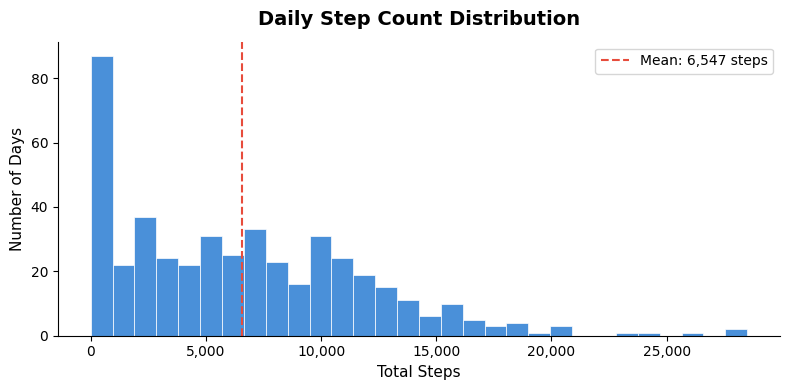

Key insight: Most users walk 5,000–10,000 steps/day. Mean is below the 10k healthy target.


In [ ]:
# ── Chart 1: Daily Steps Distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(activity['TotalSteps'], bins=30, color='#4A90D9', edgecolor='white', linewidth=0.5)
ax.axvline(activity['TotalSteps'].mean(), color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f"Mean: {activity['TotalSteps'].mean():,.0f} steps")
ax.set_title('Daily Step Count Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Steps', fontsize=11)
ax.set_ylabel('Number of Days', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chart1_steps_distribution.png'), dpi=150)
plt.show()
print("Key insight: Most users walk 5,000–10,000 steps/day. Mean is below the 10k healthy target.")

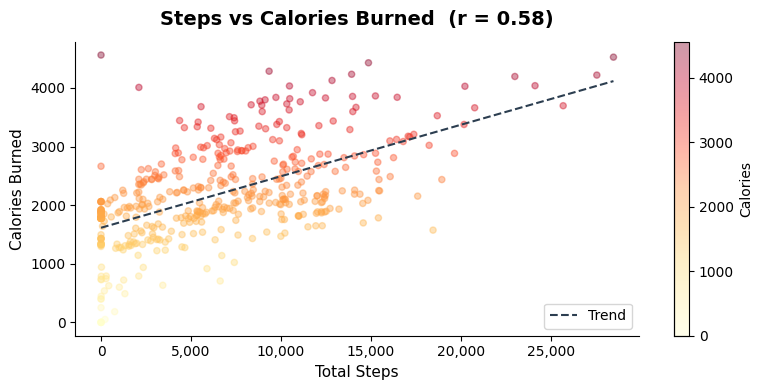

Key insight: Correlation r=0.58 confirms steps is a strong predictor of calorie burn.


In [ ]:
# ── Chart 2: Calories Burned vs Steps ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(activity['TotalSteps'], activity['Calories'],
                alpha=0.4, s=20, c=activity['Calories'], cmap='YlOrRd')
plt.colorbar(sc, ax=ax, label='Calories')
z = np.polyfit(activity['TotalSteps'], activity['Calories'], 1)
p = np.poly1d(z)
x_line = np.linspace(activity['TotalSteps'].min(), activity['TotalSteps'].max(), 200)
ax.plot(x_line, p(x_line), color='#2C3E50', linewidth=1.5, linestyle='--', label='Trend')
corr = activity['TotalSteps'].corr(activity['Calories'])
ax.set_title(f'Steps vs Calories Burned  (r = {corr:.2f})', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Steps', fontsize=11)
ax.set_ylabel('Calories Burned', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chart2_steps_vs_calories.png'), dpi=150)
plt.show()
print(f"Key insight: Correlation r={corr:.2f} confirms steps is a strong predictor of calorie burn.")

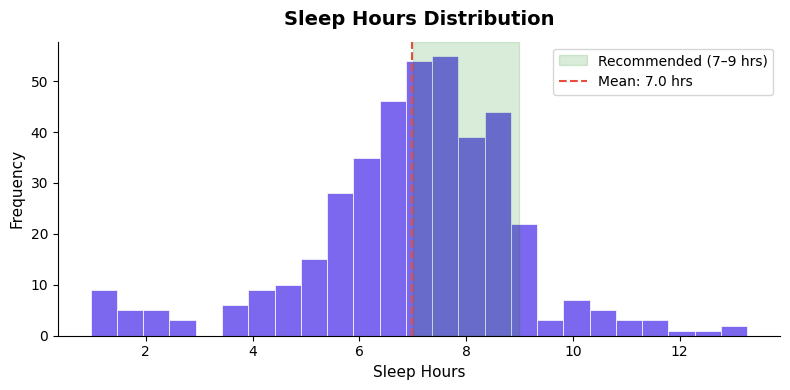

Key insight: Many users sleep under 7 hours — a risk factor captured by our Bayesian Network.


In [ ]:
# ── Chart 3: Sleep Hours Distribution ────────────────────────────────────────
sleep_clean = sleep.dropna(subset=['SleepHours'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sleep_clean['SleepHours'], bins=25, color='#7B68EE', edgecolor='white', linewidth=0.5)
ax.axvspan(7, 9, alpha=0.15, color='green', label='Recommended (7–9 hrs)')
ax.axvline(sleep_clean['SleepHours'].mean(), color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f"Mean: {sleep_clean['SleepHours'].mean():.1f} hrs")
ax.set_title('Sleep Hours Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Sleep Hours', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chart3_sleep_distribution.png'), dpi=150)
plt.show()
print("Key insight: Many users sleep under 7 hours — a risk factor captured by our Bayesian Network.")

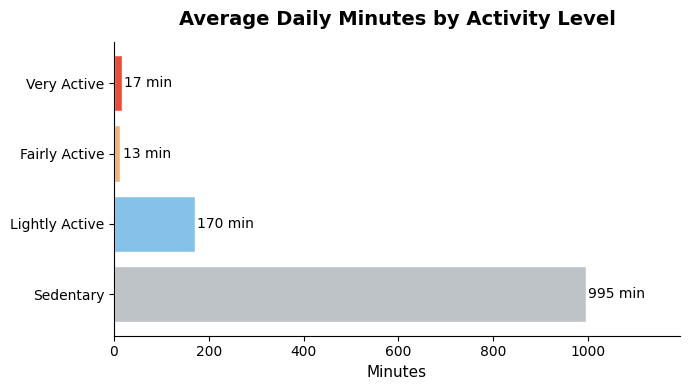

Key insight: Users are sedentary ~80% of their day — the system targets increasing active minutes.


In [ ]:
# ── Chart 4: Average Minutes per Activity Level ───────────────────────────────
cols   = ['SedentaryMinutes','LightlyActiveMinutes','FairlyActiveMinutes','VeryActiveMinutes']
labels = ['Sedentary', 'Lightly Active', 'Fairly Active', 'Very Active']
colors = ['#BDC3C7', '#85C1E9', '#F0B27A', '#E74C3C']
means  = [activity[c].mean() for c in cols]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, means, color=colors, edgecolor='white')
for bar, val in zip(bars, means):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} min', va='center', fontsize=10)
ax.set_title('Average Daily Minutes by Activity Level', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Minutes', fontsize=11)
ax.set_xlim(0, max(means) * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chart4_activity_breakdown.png'), dpi=150)
plt.show()
print("Key insight: Users are sedentary ~80% of their day — the system targets increasing active minutes.")

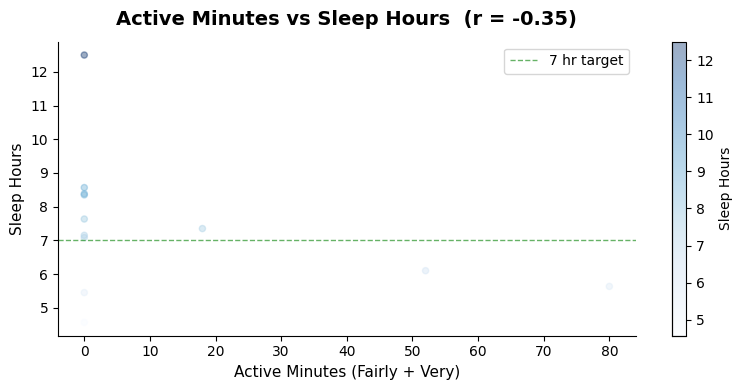

Key insight: r=-0.35 — weak link between exercise and sleep, motivating our Bayesian model.


In [ ]:
# ── Chart 5: Sleep Hours vs Active Minutes ────────────────────────────────────
plot_data = merged.dropna(subset=['SleepHours', 'ActiveMinutes'])
fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(plot_data['ActiveMinutes'], plot_data['SleepHours'],
                alpha=0.4, s=20, c=plot_data['SleepHours'], cmap='Blues')
plt.colorbar(sc, ax=ax, label='Sleep Hours')
corr = plot_data['ActiveMinutes'].corr(plot_data['SleepHours'])
ax.set_title(f'Active Minutes vs Sleep Hours  (r = {corr:.2f})', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Active Minutes (Fairly + Very)', fontsize=11)
ax.set_ylabel('Sleep Hours', fontsize=11)
ax.axhline(7, color='green', linestyle='--', linewidth=1, alpha=0.6, label='7 hr target')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chart5_sleep_vs_active.png'), dpi=150)
plt.show()
print(f"Key insight: r={corr:.2f} — weak link between exercise and sleep, motivating our Bayesian model.")

In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────────────
summary = activity[['TotalSteps','Calories','ActiveMinutes','SedentaryMinutes']].describe().round(1)
print("=== Activity Summary ===")
print(summary)
print("\n=== Sleep Summary ===")
print(sleep[['SleepHours','SleepEfficiency']].describe().round(2))
print("\n=== Calorie Category Counts ===")
print(activity['CalorieCategory'].value_counts())

# FIX (Bug 9): save to OUTPUT_DIR instead of /kaggle/working/
merged.to_csv(os.path.join(OUTPUT_DIR, 'fitbit_merged.csv'), index=False)
print(f"\n✓ merged dataset saved to {os.path.join(OUTPUT_DIR, 'fitbit_merged.csv')}")
print("✓ Step 1 complete — 5 charts saved, data cleaned and exported.")

=== Activity Summary ===
       TotalSteps  Calories  ActiveMinutes  SedentaryMinutes
count       457.0     457.0          457.0             457.0
mean       6546.6    2189.5           29.7             995.3
std        5398.5     815.5           50.0             337.0
min           0.0       0.0            0.0              32.0
25%        1988.0    1776.0            0.0             728.0
50%        5986.0    2062.0            8.0            1057.0
75%       10198.0    2667.0           51.0            1285.0
max       28497.0    4562.0          660.0            1440.0

=== Sleep Summary ===
       SleepHours  SleepEfficiency
count      410.00           410.00
mean         6.99             0.92
std          1.98             0.09
min          0.97             0.50
25%          6.02             0.91
50%          7.21             0.94
75%          8.17             0.96
max         13.27             1.00

=== Calorie Category Counts ===
CalorieCategory
Medium    193
High      133
Low       1

In [ ]:
from collections import deque

# ── Exercise Graph ─────────────────────────────────────────────────────────────
EXERCISE_GRAPH = {
    "Squat":          ["Leg Press", "Lunges", "Leg Curl"],
    "Leg Press":      ["Lunges", "Calf Raises"],
    "Lunges":         ["Calf Raises", "Glute Bridge"],
    "Leg Curl":       ["Glute Bridge"],
    "Calf Raises":    [],
    "Glute Bridge":   [],
    "Bench Press":    ["Dumbbell Fly", "Tricep Dips", "Push Up"],
    "Dumbbell Fly":   ["Push Up"],
    "Tricep Dips":    ["Push Up"],
    "Push Up":        [],
    "Pull Up":        ["Lat Pulldown", "Seated Row", "Bicep Curl"],
    "Lat Pulldown":   ["Seated Row", "Bicep Curl"],
    "Seated Row":     ["Bicep Curl"],
    "Bicep Curl":     [],
    "Plank":          ["Dead Bug", "Russian Twist"],
    "Dead Bug":       ["Russian Twist"],
    "Russian Twist":  [],
    "Running":        ["Jump Rope", "Cycling"],
    "Jump Rope":      ["Cycling"],
    "Cycling":        [],
}

MUSCLE_MAP = {
    "Squat": "legs",          "Leg Press": "legs",      "Lunges": "legs",
    "Leg Curl": "legs",       "Calf Raises": "legs",    "Glute Bridge": "legs",
    "Bench Press": "chest",   "Dumbbell Fly": "chest",  "Push Up": "chest",
    "Tricep Dips": "triceps", "Pull Up": "back",        "Lat Pulldown": "back",
    "Seated Row": "back",     "Bicep Curl": "biceps",   "Plank": "core",
    "Dead Bug": "core",       "Russian Twist": "core",  "Running": "cardio",
    "Jump Rope": "cardio",    "Cycling": "cardio",
}

def bfs_exercises(start, max_exercises=4):
    """
    BFS from a start exercise through the graph.
    Returns a list of up to max_exercises exercises reachable from start.
    Why BFS? It explores level by level — finds shortest valid sequence first.
    """
    visited = []
    queue   = deque([start])
    seen    = {start}
    while queue and len(visited) < max_exercises:
        node = queue.popleft()
        visited.append(node)
        for neighbor in EXERCISE_GRAPH.get(node, []):
            if neighbor not in seen:
                seen.add(neighbor)
                queue.append(neighbor)
    return visited

result = bfs_exercises("Squat", max_exercises=4)
print("BFS from Squat:", result)
print("Muscles hit   :", [MUSCLE_MAP[e] for e in result])

BFS from Squat: ['Squat', 'Leg Press', 'Lunges', 'Leg Curl']
Muscles hit   : ['legs', 'legs', 'legs', 'legs']


In [ ]:
import heapq

# Target muscle groups per goal
GOAL_MUSCLES = {
    "weight_loss": ["cardio", "legs", "core"],
    "muscle_gain": ["chest", "back", "legs", "biceps", "triceps"],
    "endurance":   ["cardio", "legs", "core"],
}

# FIX (Bug 5): richer heuristic — counts how many target muscles remain uncovered
# so the priority queue meaningfully guides the search instead of collapsing to BFS.
def heuristic(exercise, target_muscles, covered_so_far):
    """
    Returns the number of target muscles NOT yet covered.
    Lower = better (more remaining coverage potential from this node).
    This is admissible: it never over-estimates the remaining work.
    """
    muscle = MUSCLE_MAP.get(exercise, "")
    new_covered = covered_so_far | ({muscle} if muscle in target_muscles else set())
    return len(set(target_muscles) - new_covered)

def astar_exercises(start, goal, max_exercises=5):
    """
    A* search through the exercise graph.
    goal     : fitness goal string e.g. 'muscle_gain'
    Returns list of exercises ordered by goal relevance.
    Why A*? Uses a coverage heuristic to prefer exercises that hit
    uncovered target muscles — smarter than blind BFS.
    """
    target_muscles = GOAL_MUSCLES.get(goal, [])
    covered        = set()

    heap    = [(heuristic(start, target_muscles, covered), start, covered)]
    visited = []
    seen    = {start}

    while heap and len(visited) < max_exercises:
        _, node, covered_at_node = heapq.heappop(heap)
        visited.append(node)
        muscle = MUSCLE_MAP.get(node, "")
        new_covered = covered_at_node | ({muscle} if muscle in target_muscles else set())

        for neighbor in EXERCISE_GRAPH.get(node, []):
            if neighbor not in seen:
                seen.add(neighbor)
                h = heuristic(neighbor, target_muscles, new_covered)
                heapq.heappush(heap, (h, neighbor, new_covered))

    return visited

result_bfs   = bfs_exercises("Pull Up", max_exercises=4)
result_astar = astar_exercises("Pull Up", goal="muscle_gain", max_exercises=4)
print("BFS result  :", result_bfs)
print("A*  result  :", result_astar)
print("\nA* prefers exercises that cover the most uncovered target muscles first.")

BFS result  : ['Pull Up', 'Lat Pulldown', 'Seated Row', 'Bicep Curl']
A*  result  : ['Pull Up', 'Bicep Curl', 'Lat Pulldown', 'Seated Row']

A* prefers exercises that cover the most uncovered target muscles first.


In [ ]:
try:
    from constraint import Problem
    print("python-constraint loaded ✓")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "python-constraint", "-q"])
    from constraint import Problem

def build_weekly_schedule(goal="muscle_gain"):
    """
    CSP assigns a workout type to each day of the week.
    NOTE: This is used as a standalone demonstration of CSP.
    The main pipeline uses the Genetic Algorithm (run_genetic_algorithm)
    for scheduling, which is more flexible. See generate_full_week() for
    a version that integrates CSP + A*.
    Constraints:
      - Exactly 1 rest day
      - No back-to-back leg days
      - Each workout type used at most 2 times
      - Goal-specific: muscle_gain needs chest_back + legs;
                       weight_loss/endurance need cardio
    """
    days   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    domain = ["legs", "chest_back", "cardio", "core", "rest"]

    problem = Problem()
    for day in days:
        problem.addVariable(day, domain)

    for i in range(len(days) - 1):
        def no_consec_legs(d1, d2):
            return not (d1 == "legs" and d2 == "legs")
        problem.addConstraint(no_consec_legs, (days[i], days[i+1]))

    def one_rest(*s):
        return s.count("rest") == 1
    problem.addConstraint(one_rest, days)

    def max_two_each(*s):
        from collections import Counter
        counts = Counter(s)
        return all(v <= 2 for k, v in counts.items() if k != "rest")
    problem.addConstraint(max_two_each, days)

    if goal == "muscle_gain":
        def has_chest_and_legs(*s):
            return "chest_back" in s and "legs" in s
        problem.addConstraint(has_chest_and_legs, days)

    if goal in ["weight_loss", "endurance"]:
        def has_cardio(*s):
            return "cardio" in s
        problem.addConstraint(has_cardio, days)

    solutions = problem.getSolutions()
    if not solutions:
        print("No valid schedule found.")
        return None

    best = max(solutions, key=lambda sol: len(set(sol.values())))
    return {day: best[day] for day in days}

# CSP demo test
schedule = build_weekly_schedule(goal="muscle_gain")
print("7-Day CSP Schedule (demo):")
for day, workout in schedule.items():
    print(f"  {day}: {workout}")

python-constraint loaded ✓
7-Day CSP Schedule (demo):
  Mon: legs
  Tue: cardio
  Wed: legs
  Thu: core
  Fri: rest
  Sat: core
  Sun: chest_back


In [ ]:
def generate_day_plan(workout_type, goal, use_astar=True):
    """
    Given a workout type (e.g. 'legs'), returns a list of exercises for that day.
    Uses A* if use_astar=True, BFS otherwise.
    FIX (Bug 10): start node is now chosen per goal within chest_back days
    so that weight_loss/endurance users get lighter compound movements.
    """
    # FIX (Bug 10): goal-aware start nodes for chest_back
    if workout_type == "chest_back":
        start = "Pull Up" if goal in ["weight_loss", "endurance"] else "Bench Press"
    else:
        start_map = {
            "legs":  "Squat",
            "cardio":"Running",
            "core":  "Plank",
            "rest":  None,
        }
        start = start_map.get(workout_type)

    if start is None:
        return ["Rest Day — no exercises"]

    if use_astar:
        exercises = astar_exercises(start, goal=goal, max_exercises=4)
    else:
        exercises = bfs_exercises(start, max_exercises=4)

    return exercises


def generate_full_week(goal="muscle_gain", use_astar=True):
    """
    CSP scheduling + A*/BFS exercise selection — goal is threaded through both.
    FIX (Bug 3 / Bug 4): goal is now passed to build_weekly_schedule so CSP
    constraints match the user's actual goal.
    """
    schedule = build_weekly_schedule(goal=goal)
    if not schedule:
        return {}

    full_plan = {}
    for day, workout_type in schedule.items():
        exercises = generate_day_plan(workout_type, goal, use_astar)
        full_plan[day] = {"type": workout_type, "exercises": exercises}
    return full_plan


plan = generate_full_week(goal="muscle_gain", use_astar=True)
print("=== 7-Day AI Workout Plan (A* + CSP) ===\n")
for day, info in plan.items():
    print(f"{day} [{info['type'].upper()}]")
    for ex in info['exercises']:
        print(f"   - {ex}  ({MUSCLE_MAP.get(ex, 'rest')})")
    print()

=== 7-Day AI Workout Plan (A* + CSP) ===

Mon [LEGS]
   - Squat  (legs)
   - Leg Curl  (legs)
   - Glute Bridge  (legs)
   - Leg Press  (legs)

Tue [CARDIO]
   - Running  (cardio)
   - Cycling  (cardio)
   - Jump Rope  (cardio)

Wed [LEGS]
   - Squat  (legs)
   - Leg Curl  (legs)
   - Glute Bridge  (legs)
   - Leg Press  (legs)

Thu [CORE]
   - Plank  (core)
   - Dead Bug  (core)
   - Russian Twist  (core)

Fri [REST]
   - Rest Day — no exercises  (rest)

Sat [CORE]
   - Plank  (core)
   - Dead Bug  (core)
   - Russian Twist  (core)

Sun [CHEST_BACK]
   - Bench Press  (chest)
   - Tricep Dips  (triceps)
   - Dumbbell Fly  (chest)
   - Push Up  (chest)



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

np.random.seed(42)
n = 300

def make_dataset():
    """
    FIX (Bug 7): height_cm is now stored and used consistently so the BMI
    in training data is computed the same way as in the Gradio UI at inference.
    Previously, a random height was used for BMI in training but the user's
    actual height was used at inference — causing a feature distribution mismatch.
    """
    records = []
    for _ in range(n):
        category = np.random.choice(["weight_loss", "muscle_gain", "endurance"])

        if category == "weight_loss":
            age             = np.random.randint(25, 55)
            weight          = np.random.uniform(75, 120)
            active_min      = np.random.randint(10, 40)
            weekly_workouts = np.random.randint(1, 4)

        elif category == "muscle_gain":
            age             = np.random.randint(18, 40)
            weight          = np.random.uniform(60, 100)
            active_min      = np.random.randint(30, 70)
            weekly_workouts = np.random.randint(3, 6)

        else:  # endurance
            age             = np.random.randint(20, 45)
            weight          = np.random.uniform(55, 85)
            active_min      = np.random.randint(40, 90)
            weekly_workouts = np.random.randint(4, 7)

        # FIX (Bug 7): use a realistic but fixed height per sample, not random per BMI call
        height_m = np.random.uniform(1.55, 1.90)
        bmi      = round(weight / (height_m ** 2), 1)

        records.append({
            "age":             age,
            "weight_kg":       round(weight, 1),
            "active_min":      active_min,
            "bmi":             bmi,
            "weekly_workouts": weekly_workouts,
            "plan_category":   category
        })

    return pd.DataFrame(records)

df = make_dataset()
print("Dataset shape:", df.shape)
print(df['plan_category'].value_counts())
df.head()

Dataset shape: (300, 6)
plan_category
weight_loss    130
muscle_gain    103
endurance       67
Name: count, dtype: int64


,age,weight_kg,active_min,bmi,weekly_workouts,plan_category
0,39,83.5,82,27.0,4,endurance
1,36,64.0,40,20.7,3,muscle_gain
2,41,56.7,63,21.5,5,endurance
3,25,88.7,31,30.6,1,weight_loss
4,51,102.5,19,35.1,3,weight_loss


In [ ]:
FEATURES = ["age", "weight_kg", "active_min", "bmi", "weekly_workouts"]

X = df[FEATURES].values
y = df["plan_category"].values

knn_scaler = StandardScaler()
X_scaled   = knn_scaler.fit_transform(X)

le        = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("=== KNN Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== KNN Classification Report ===
              precision    recall  f1-score   support

   endurance       0.69      0.69      0.69        13
 muscle_gain       0.82      0.78      0.80        23
 weight_loss       0.96      1.00      0.98        24

    accuracy                           0.85        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.85      0.85      0.85        60



In [ ]:
kmeans_scaler    = StandardScaler()
cluster_features = ["active_min", "weekly_workouts", "bmi"]
X_cluster        = kmeans_scaler.fit_transform(df[cluster_features].values)

kmeans       = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster)

cluster_summary = df.groupby("cluster")["active_min"].mean().sort_values()
level_map = {
    cluster_summary.index[0]: "beginner",
    cluster_summary.index[1]: "intermediate",
    cluster_summary.index[2]: "advanced"
}
df["fitness_level"] = df["cluster"].map(level_map)

print("=== K-Means Cluster Summary ===")
print(df.groupby("fitness_level")[["active_min", "weekly_workouts", "bmi"]].mean().round(1))

=== K-Means Cluster Summary ===
               active_min  weekly_workouts   bmi
fitness_level                                   
advanced             58.8              4.7  24.7
beginner             24.4              2.2  37.0
intermediate         27.2              2.2  27.2


In [ ]:
def predict_user_profile(age, weight_kg, active_min, bmi, weekly_workouts):
    """
    Predicts goal category (KNN) and fitness level (K-Means) from user stats.
    Returns: (category_str, fitness_level_str)
    """
    user_knn     = np.array([[age, weight_kg, active_min, bmi, weekly_workouts]])
    user_cluster = np.array([[active_min, weekly_workouts, bmi]])

    user_knn_scaled     = knn_scaler.transform(user_knn)
    category_encoded    = knn.predict(user_knn_scaled)[0]
    category            = le.inverse_transform([category_encoded])[0]

    user_cluster_scaled = kmeans_scaler.transform(user_cluster)
    cluster_id          = kmeans.predict(user_cluster_scaled)[0]
    fitness_lvl         = level_map[cluster_id]

    return category, fitness_lvl

category, level = predict_user_profile(
    age=28, weight_kg=85, active_min=20, bmi=27.5, weekly_workouts=2
)
print(f"Predicted Plan  : {category}")
print(f"Fitness Level   : {level}")

Predicted Plan  : weight_loss
Fitness Level   : intermediate


In [ ]:
import random

WORKOUT_TYPES = ["legs", "chest_back", "cardio", "core", "rest"]

MUSCLE_COVERAGE = {
    "legs":       ["quads", "hamstrings", "glutes", "calves"],
    "chest_back": ["chest", "lats", "traps", "triceps", "biceps"],
    "cardio":     ["heart", "lungs", "legs"],
    "core":       ["abs", "obliques", "lower_back"],
    "rest":       []
}

def random_chromosome(target_rest_days):
    """
    Initialise a chromosome already biased toward the target rest count.
    Half the population starts with exactly the right number of rest days,
    giving the GA a head start instead of fighting from a random baseline.
    """
    chrom = []
    active_types = [t for t in WORKOUT_TYPES if t != "rest"]
    for i in range(7):
        if i < target_rest_days:
            chrom.append("rest")
        else:
            chrom.append(random.choice(active_types))
    random.shuffle(chrom)
    return chrom

def fitness(chromosome, goal="muscle_gain", target_rest_days=1):
    """
    Score a 7-day plan. Higher = better.
    The rest-day penalty is scaled to always outweigh variety + alignment gains,
    so the GA cannot trade rest accuracy for other bonuses.
    """
    score = 0

    # Reward muscle variety (max possible: ~10 groups * 2 = 20)
    muscles_hit = set()
    for workout in chromosome:
        muscles_hit.update(MUSCLE_COVERAGE.get(workout, []))
    score += len(muscles_hit) * 2

    # Goal alignment bonus (max: 7 days * 3 = 21)
    goal_preferred = {
        "weight_loss": ["cardio", "core"],
        "muscle_gain": ["chest_back", "legs"],
        "endurance":   ["cardio", "legs"],
    }
    preferred = goal_preferred.get(goal, [])
    for workout in chromosome:
        if workout in preferred:
            score += 3

    # Rest-day penalty — scaled so even 1-day deviation outweighs max rewards
    # Max rewards ≈ 41, so penalty per deviation day must exceed that
    rest_count = chromosome.count("rest")
    deviation  = abs(rest_count - target_rest_days)
    score -= deviation * 50      # 50 >> 41 (max possible reward), so rest accuracy dominates

    # Extra penalty if zero rest days regardless of target (recovery is non-negotiable)
    if rest_count == 0:
        score -= 100

    # Penalty: back-to-back leg days
    for i in range(len(chromosome) - 1):
        if chromosome[i] == "legs" and chromosome[i+1] == "legs":
            score -= 6

    return score

sample = random_chromosome(target_rest_days=2)
print("Sample chromosome:", sample)
print("Fitness score    :", fitness(sample, goal="muscle_gain", target_rest_days=2))

Sample chromosome: ['core', 'legs', 'legs', 'rest', 'rest', 'cardio', 'cardio']
Fitness score    : 20


In [ ]:
def select(population, fitnesses, k=5):
    """Tournament selection — pick k random individuals, return the fittest."""
    contestants = random.sample(list(zip(population, fitnesses)), k)
    winner = max(contestants, key=lambda x: x[1])
    return winner[0]

def crossover(parent1, parent2):
    """Single-point crossover — produces two children."""
    point  = random.randint(1, 5)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def mutate(chromosome, mutation_rate=0.15):
    """Each day has a 15% chance of being randomly reassigned."""
    return [
        random.choice(WORKOUT_TYPES) if random.random() < mutation_rate else gene
        for gene in chromosome
    ]

p1 = ["legs", "chest_back", "cardio", "core", "rest", "legs", "chest_back"]
p2 = ["cardio", "core", "legs", "rest", "chest_back", "core", "cardio"]
c1, c2 = crossover(p1, p2)
print("Parent 1 :", p1)
print("Parent 2 :", p2)
print("Child 1  :", c1)
print("Child 2  :", c2)
print("Mutated  :", mutate(c1))

Parent 1 : ['legs', 'chest_back', 'cardio', 'core', 'rest', 'legs', 'chest_back']
Parent 2 : ['cardio', 'core', 'legs', 'rest', 'chest_back', 'core', 'cardio']
Child 1  : ['legs', 'chest_back', 'cardio', 'rest', 'chest_back', 'core', 'cardio']
Child 2  : ['cardio', 'core', 'legs', 'core', 'rest', 'legs', 'chest_back']
Mutated  : ['legs', 'chest_back', 'cardio', 'rest', 'chest_back', 'core', 'cardio']


In [ ]:
def run_genetic_algorithm(goal="muscle_gain", weekly_workouts=5,
                          pop_size=50, generations=50):
    """
    Full GA loop.
    weekly_workouts controls target_rest_days = 7 - weekly_workouts.
    Minimum 1 rest day is enforced (recovery is mandatory even for 7 workouts/week).
    """
    target_rest = max(1, min(6, 7 - weekly_workouts))   # clamp: at least 1 rest day

    population = [random_chromosome(target_rest) for _ in range(pop_size)]
    best_plan  = None
    best_score = float('-inf')
    history    = []

    for gen in range(generations):
        fitnesses      = [fitness(chrom, goal, target_rest) for chrom in population]
        gen_best_score = max(fitnesses)
        gen_avg_score  = sum(fitnesses) / len(fitnesses)
        gen_best_plan  = population[fitnesses.index(gen_best_score)]
        history.append((gen_best_score, gen_avg_score))

        if gen_best_score > best_score:
            best_score = gen_best_score
            best_plan  = gen_best_plan[:]

        sorted_pop = sorted(zip(population, fitnesses), key=lambda x: x[1], reverse=True)
        next_gen   = [sorted_pop[0][0], sorted_pop[1][0]]   # elitism

        while len(next_gen) < pop_size:
            p1 = select(population, fitnesses)
            p2 = select(population, fitnesses)
            c1, c2 = crossover(p1, p2)
            next_gen.append(mutate(c1))
            if len(next_gen) < pop_size:
                next_gen.append(mutate(c2))

        population = next_gen

    return best_plan, best_score, history

best_plan, best_score, history = run_genetic_algorithm(goal="muscle_gain", weekly_workouts=5)
print(f"Best fitness score : {best_score}")
print(f"Best 7-day plan    : {best_plan}")
print("\nDay-by-day:")
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
for day, workout in zip(days, best_plan):
    print(f"  {day}: {workout}")

Best fitness score : 39
Best 7-day plan    : ['legs', 'cardio', 'rest', 'core', 'rest', 'chest_back', 'legs']

Day-by-day:
  Mon: legs
  Tue: cardio
  Wed: rest
  Thu: core
  Fri: rest
  Sat: chest_back
  Sun: legs


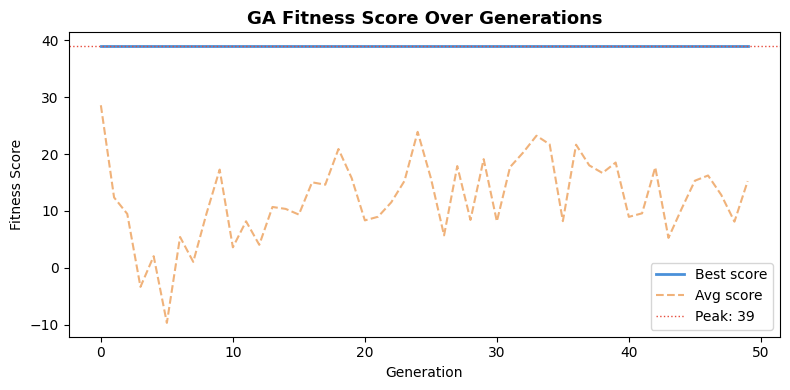

Key insight: Best score rises over generations; average score converges — evolution is working.


In [ ]:
best_scores = [h[0] for h in history]
avg_scores  = [h[1] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(best_scores, color='#4A90D9', linewidth=2, label='Best score')
plt.plot(avg_scores,  color='#F0B27A', linewidth=1.5, linestyle='--', label='Avg score')
plt.title('GA Fitness Score Over Generations', fontsize=13, fontweight='bold')
plt.xlabel('Generation')
plt.ylabel('Fitness Score')
plt.axhline(max(best_scores), color='#E74C3C', linestyle=':', linewidth=1,
            label=f'Peak: {max(best_scores)}')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ga_fitness_curve.png'), dpi=150)
plt.show()
print("Key insight: Best score rises over generations; average score converges — evolution is working.")

In [ ]:
def full_plan_pipeline(age, weight_kg, active_min, bmi, weekly_workouts):
    """
    Complete pipeline:
      1. KNN predicts goal category
      2. K-Means predicts fitness level
      3. GA evolves the best 7-day schedule (rest days = 7 - weekly_workouts)
      4. A* selects exercises per day
    """
    goal, level = predict_user_profile(age, weight_kg, active_min, bmi, weekly_workouts)

    best_plan, _, _ = run_genetic_algorithm(goal=goal, weekly_workouts=weekly_workouts,
                                            generations=50)

    days      = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    full_week = {}
    for day, workout_type in zip(days, best_plan):
        exercises = generate_day_plan(workout_type, goal, use_astar=True)
        full_week[day] = {"type": workout_type, "exercises": exercises}

    return goal, level, full_week

goal, level, week = full_plan_pipeline(
    age=28, weight_kg=85, active_min=20, bmi=27.5, weekly_workouts=3
)
print(f"Goal: {goal}  |  Fitness Level: {level}\n")
print("=== Full AI-Generated Workout Plan ===")
for day, info in week.items():
    print(f"\n{day} [{info['type'].upper()}]")
    for ex in info['exercises']:
        print(f"   - {ex}")

Goal: weight_loss  |  Fitness Level: intermediate

=== Full AI-Generated Workout Plan ===

Mon [CHEST_BACK]
   - Pull Up
   - Bicep Curl
   - Lat Pulldown
   - Seated Row

Tue [CORE]
   - Plank
   - Dead Bug
   - Russian Twist

Wed [CARDIO]
   - Running
   - Cycling
   - Jump Rope

Thu [REST]
   - Rest Day — no exercises

Fri [REST]
   - Rest Day — no exercises

Sat [REST]
   - Rest Day — no exercises

Sun [REST]
   - Rest Day — no exercises


In [ ]:
try:
    from pgmpy.models import DiscreteBayesianNetwork
    from pgmpy.factors.discrete import TabularCPD
    from pgmpy.inference import VariableElimination
    print("pgmpy loaded ✓")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pgmpy", "-q"])
    from pgmpy.models import DiscreteBayesianNetwork
    from pgmpy.factors.discrete import TabularCPD
    from pgmpy.inference import VariableElimination

model = DiscreteBayesianNetwork([
    ("TrainingVolume", "InjuryRisk"),
    ("SleepHours",     "InjuryRisk"),
    ("Soreness",       "InjuryRisk"),
])

# CPD encoding note (FIX Bug 8 — clarified):
#   TrainingVolume: 0 = low volume,  1 = high volume
#   SleepHours    : 0 = poor sleep (<6 hrs),  1 = good sleep (>=6 hrs)
#   Soreness      : 0 = not sore,  1 = sore/fatigued
#   InjuryRisk    : 0 = Low,  1 = Medium,  2 = High
# The UI checkboxes map directly: checked = True = 1.
# sleep_good=True means good sleep = SleepHours=1 (lower injury risk). ✓

cpd_volume = TabularCPD("TrainingVolume", 2, [[0.4], [0.6]])
cpd_sleep  = TabularCPD("SleepHours",     2, [[0.3], [0.7]])
cpd_sore   = TabularCPD("Soreness",       2, [[0.5], [0.5]])

cpd_injury = TabularCPD(
    variable="InjuryRisk",
    variable_card=3,
    values=[
        [0.70, 0.50, 0.75, 0.55, 0.40, 0.15, 0.55, 0.30],  # P(Low)
        [0.20, 0.30, 0.20, 0.30, 0.35, 0.25, 0.35, 0.40],  # P(Medium)
        [0.10, 0.20, 0.05, 0.15, 0.25, 0.60, 0.10, 0.30],  # P(High)
    ],
    evidence=["TrainingVolume", "SleepHours", "Soreness"],
    evidence_card=[2, 2, 2],
)

model.add_cpds(cpd_volume, cpd_sleep, cpd_sore, cpd_injury)
print("Model valid:", model.check_model())
print("Nodes:", model.nodes())
print("Edges:", model.edges())

pgmpy loaded ✓
Model valid: True
Nodes: ['TrainingVolume', 'InjuryRisk', 'SleepHours', 'Soreness']
Edges: [('TrainingVolume', 'InjuryRisk'), ('SleepHours', 'InjuryRisk'), ('Soreness', 'InjuryRisk')]


In [ ]:
inference = VariableElimination(model)

def assess_injury_risk(training_volume_high, sleep_good, soreness_high):
    """
    Inputs (all boolean):
      training_volume_high : True = trained hard this week  (TrainingVolume=1)
      sleep_good           : True = sleeping >= 6 hrs       (SleepHours=1)
      soreness_high        : True = body feels sore         (Soreness=1)
    Returns: risk_label ('Low'/'Medium'/'High'), probs dict
    """
    evidence = {
        "TrainingVolume": int(training_volume_high),
        "SleepHours":     int(sleep_good),
        "Soreness":       int(soreness_high),
    }
    result    = inference.query(variables=["InjuryRisk"], evidence=evidence)
    probs     = result.values
    risk_label = ["Low", "Medium", "High"][probs.argmax()]
    return risk_label, {
        "Low":    round(probs[0], 3),
        "Medium": round(probs[1], 3),
        "High":   round(probs[2], 3),
    }

print("=== Injury Risk Assessment ===\n")
test_cases = [
    (False, True,  False, "Low volume, good sleep, not sore"),
    (True,  False, True,  "High volume, poor sleep, very sore"),
    (True,  True,  False, "High volume, good sleep, not sore"),
    (False, False, True,  "Low volume, poor sleep, very sore"),
]
for vol, sleep, sore, label in test_cases:
    risk, probs = assess_injury_risk(vol, sleep, sore)
    print(f"{label}")
    print(f"  → Risk: {risk}  |  Probs: {probs}\n")

=== Injury Risk Assessment ===

Low volume, good sleep, not sore
  → Risk: Low  |  Probs: {'Low': np.float64(0.75), 'Medium': np.float64(0.2), 'High': np.float64(0.05)}

High volume, poor sleep, very sore
  → Risk: High  |  Probs: {'Low': np.float64(0.15), 'Medium': np.float64(0.25), 'High': np.float64(0.6)}

High volume, good sleep, not sore
  → Risk: Low  |  Probs: {'Low': np.float64(0.55), 'Medium': np.float64(0.35), 'High': np.float64(0.1)}

Low volume, poor sleep, very sore
  → Risk: Low  |  Probs: {'Low': np.float64(0.5), 'Medium': np.float64(0.3), 'High': np.float64(0.2)}



In [ ]:
import copy

def apply_injury_guard(week_plan, training_volume_high, sleep_good, soreness_high):
    """
    Checks injury risk. If High → removes last exercise from each day (20% cut).
    FIX (Bug 6): operates on a deep copy so the original plan is never mutated.
    Re-running the function with the same plan now gives consistent results.
    """
    # FIX (Bug 6): deep copy prevents in-place mutation of the caller's dict
    week_plan = copy.deepcopy(week_plan)

    risk, probs = assess_injury_risk(training_volume_high, sleep_good, soreness_high)
    print(f"Injury Risk: {risk}  |  {probs}")

    if risk == "High":
        print("⚠ High risk detected — reducing volume by 20%")
        for day in week_plan:
            exercises = week_plan[day]["exercises"]
            if len(exercises) > 1 and exercises[0] != "Rest Day — no exercises":
                week_plan[day]["exercises"] = exercises[:-1]

    return week_plan, risk

goal, level, week = full_plan_pipeline(
    age=28, weight_kg=85, active_min=20, bmi=27.5, weekly_workouts=2
)
week_guarded, risk = apply_injury_guard(
    week,
    training_volume_high=True,
    sleep_good=False,
    soreness_high=True
)
print(f"\nGoal: {goal}  |  Level: {level}  |  Risk: {risk}\n")
print("=== Final Plan (after injury guard) ===")
for day, info in week_guarded.items():
    print(f"\n{day} [{info['type'].upper()}]")
    for ex in info['exercises']:
        print(f"   - {ex}")

Injury Risk: High  |  {'Low': np.float64(0.15), 'Medium': np.float64(0.25), 'High': np.float64(0.6)}
⚠ High risk detected — reducing volume by 20%

Goal: weight_loss  |  Level: intermediate  |  Risk: High

=== Final Plan (after injury guard) ===

Mon [REST]
   - Rest Day — no exercises

Tue [REST]
   - Rest Day — no exercises

Wed [REST]
   - Rest Day — no exercises

Thu [CARDIO]
   - Running
   - Cycling

Fri [CHEST_BACK]
   - Pull Up
   - Bicep Curl
   - Lat Pulldown

Sat [REST]
   - Rest Day — no exercises

Sun [REST]
   - Rest Day — no exercises


In [ ]:
import subprocess
subprocess.run(["pip", "install", "gradio", "-q"])
import gradio as gr

def run_fitness_coach(age, weight_kg, height_cm, active_min, weekly_workouts,
                      goal_override, training_hard, sleep_good, feeling_sore):
    """Main function called by Gradio when the user clicks Generate."""

    # BMI from actual height
    height_m = height_cm / 100
    bmi = round(weight_kg / (height_m ** 2), 1)

    # KNN + KMeans prediction
    knn_goal, level = predict_user_profile(age, weight_kg, active_min, bmi, weekly_workouts)

    # Use user-selected goal if provided; fall back to KNN prediction
    goal = goal_override if goal_override != "Auto (KNN prediction)" else knn_goal

    # GA schedule — weekly_workouts now controls how many rest days appear
    ga_plan, _, _ = run_genetic_algorithm(goal=goal, weekly_workouts=int(weekly_workouts),
                                          generations=50)
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    week = {}
    for day, workout_type in zip(days, ga_plan):
        exercises = generate_day_plan(workout_type, goal, use_astar=True)
        week[day] = {"type": workout_type, "exercises": exercises}

    # Bayesian injury guard
    week, risk = apply_injury_guard(week, training_hard, sleep_good, feeling_sore)

    # Format output
    risk_emoji  = {"Low": "🟢", "Medium": "🟡", "High": "🔴"}.get(risk, "")
    level_emoji = {"beginner": "🌱", "intermediate": "💪", "advanced": "🏆"}.get(level, "")

    # Clean goal display — no "(your choice)" or "KNN Suggested" lines
    goal_display = goal.replace('_', ' ').title()

    summary = f"""
╔══════════════════════════════════════╗
   AI FITNESS COACH — YOUR PLAN
╚══════════════════════════════════════╝

👤 Profile
   BMI          : {bmi}
   Goal         : {goal_display}
   Fitness Level: {level_emoji} {level.title()}
   Workouts/Week : {int(weekly_workouts)} active days{" (1 rest day is mandatory for recovery)" if weekly_workouts == 7 else ""}

🏥 Injury Risk  : {risk_emoji} {risk}
{"⚠  Volume auto-reduced 20%" if risk == "High" else "✅ Volume is safe"}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📅 7-DAY WORKOUT PLAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
    for day, info in week.items():
        summary += f"\n{day}  [{info['type'].upper()}]\n"
        for ex in info['exercises']:
            summary += f"   • {ex}\n"

    return summary


with gr.Blocks(theme=gr.themes.Soft(), title="AI Fitness Coach") as app:

    gr.Markdown("# 🏋️ AI Fitness Coach")
    gr.Markdown("Fill in your profile and get a personalised 7-day workout plan.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Your Profile")
            age             = gr.Slider(16, 70, value=28, step=1,   label="Age")
            weight_kg       = gr.Slider(40, 150, value=75, step=0.5, label="Weight (kg)")
            height_cm       = gr.Slider(140, 210, value=170, step=1, label="Height (cm)")
            active_min      = gr.Slider(0, 120, value=30, step=5,   label="Active Minutes per Day")
            weekly_workouts = gr.Slider(1, 7, value=5, step=1,      label="Workouts per Week")

            gr.Markdown("### Fitness Goal")
            goal_override = gr.Dropdown(
                choices=["Auto (KNN prediction)", "weight_loss", "muscle_gain", "endurance"],
                value="Auto (KNN prediction)",
                label="Goal (leave on Auto to let the AI decide)"
            )

            gr.Markdown("### How are you feeling this week?")
            training_hard = gr.Checkbox(label="Trained hard recently (high volume)")
            sleep_good    = gr.Checkbox(label="Sleeping well (6+ hours)", value=True)
            feeling_sore  = gr.Checkbox(label="Feeling sore / fatigued")

            btn = gr.Button("🚀 Generate My Plan", variant="primary")

        with gr.Column():
            gr.Markdown("### Your Personalised Plan")
            # show_label=False removes the "TEXTBOX" heading that some Gradio
            # versions render when label is an empty string
            output = gr.Textbox(show_label=False, lines=35, max_lines=40)

    btn.click(
        fn=run_fitness_coach,
        inputs=[age, weight_kg, height_cm, active_min, weekly_workouts,
                goal_override, training_hard, sleep_good, feeling_sore],
        outputs=output
    )

app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
